# Cargar el modelo ViT-B/16 fine-tuned en Food-101

Este notebook carga el checkpoint generado por `vit_b16_food101_finetune.ipynb` y permite:

1. Reconstruir la arquitectura con `timm` y cargar los pesos guardados.
2. Predecir sobre **una imagen propia** (sube una foto de comida).
3. Visualizar la prediccion top-5 con su probabilidad.

Funciona en **Google Colab** (lee desde tu Drive) y en **local** (lee desde `../models/`).

## 1) Dependencias e imports

In [11]:
# Descomenta si hace falta:
# pip install -q timm torch torchvision matplotlib pillow

In [12]:
import os
import torch
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('timm version:', timm.__version__)

Device: cuda
timm version: 1.0.26


## 2) Localizar el checkpoint

Igual que al guardar: si estamos en Colab montamos Drive y leemos de ahi; si no, leemos de `../models/`.

In [13]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    MODELS_DIR = '/content/drive/MyDrive/Proyecto-Clasificador/models'
    print('Entorno: Google Colab -> leyendo de Drive')
except ImportError:
    MODELS_DIR = '../models'
    print('Entorno: local -> leyendo de', MODELS_DIR)

ckpt_path = os.path.join(MODELS_DIR, 'vit_b16_food101_finetuned.pth')
assert os.path.exists(ckpt_path), f'No existe el checkpoint en {ckpt_path}'
print(f'Checkpoint: {ckpt_path}  ({os.path.getsize(ckpt_path)/1e6:.1f} MB)')

Entorno: local -> leyendo de ../models
Checkpoint: ../models\vit_b16_food101_finetuned.pth  (343.6 MB)


## 3) Reconstruir el modelo y cargar pesos

Usamos `pretrained=False` porque NO queremos descargar los pesos originales de ImageNet: vamos a sobreescribirlos con los nuestros.

In [14]:
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

model = timm.create_model(
    ckpt['arch'],
    pretrained=False,
    num_classes=ckpt['num_classes'],
)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(device).eval()

CLASSES = ckpt['classes']
NUM_CLASSES = ckpt['num_classes']

print(f'Arquitectura: {ckpt["arch"]}')
print(f'Clases: {NUM_CLASSES}')
print(f'Test top-1 reportado: {ckpt["test_top1"]*100:.2f}%')
print(f'Test top-5 reportado: {ckpt["test_top5"]*100:.2f}%')

Arquitectura: vit_base_patch16_224.augreg_in21k_ft_in1k
Clases: 101
Test top-1 reportado: 91.80%
Test top-5 reportado: 98.65%


## 4) Transform de inferencia

Usamos exactamente el mismo preprocesamiento que en evaluacion: `Resize(256)` + `CenterCrop(224)` + normalizacion ImageNet.

In [15]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## 5) Predecir sobre una imagen

Cambia `IMG_PATH` por la ruta de tu imagen. En Colab puedes subir un archivo con el icono de la carpeta del panel izquierdo o usar `files.upload()`.

In [16]:
IMG_PATH = 'data\\prueba_food101\\mexico-pozole.jpg'   # <-- cambia esto por tu imagen

def predecir(img_path, topk=5):
    img = Image.open(img_path).convert('RGB')
    x = eval_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    top_idx = probs.argsort()[::-1][:topk]
    top = [(CLASSES[i].replace('_', ' '), float(probs[i])) for i in top_idx]
    return img, top

if os.path.exists(IMG_PATH):
    img, top5 = predecir(IMG_PATH, topk=5)
    print('Top-5 predicciones:')
    for name, p in top5:
        print(f'  {name:30s} {p*100:6.2f}%')
else:
    print(f'No existe {IMG_PATH}. Cambia IMG_PATH por una ruta valida.')

Top-5 predicciones:
  hot and sour soup               47.04%
  ceviche                         16.65%
  ramen                            8.64%
  pho                              3.48%
  tuna tartare                     2.35%


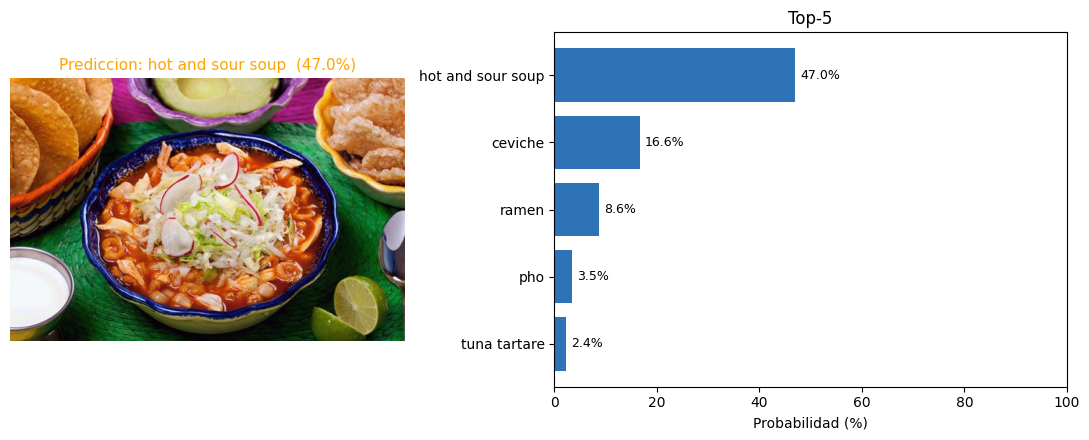

In [17]:
# Visualizacion: imagen + barras horizontales con top-5
if os.path.exists(IMG_PATH):
    img, top5 = predecir(IMG_PATH, topk=5)
    names = [n for n, _ in top5][::-1]   # invertido para que la mejor quede arriba
    probs = [p for _, p in top5][::-1]

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5),
                            gridspec_kw={'width_ratios': [1, 1.3]})
    ax[0].imshow(img); ax[0].axis('off')
    ax[0].set_title(f'Prediccion: {top5[0][0]}  ({top5[0][1]*100:.1f}%)',
                    fontsize=11, color='green' if top5[0][1] > 0.5 else 'orange')

    bars = ax[1].barh(names, [p*100 for p in probs], color='#2F73B7')
    ax[1].set_xlim(0, 100); ax[1].set_xlabel('Probabilidad (%)')
    ax[1].set_title('Top-5')
    for bar, p in zip(bars, probs):
        ax[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                   f'{p*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

## 6) Predecir sobre varias imagenes

Si tienes una carpeta con varias fotos, esta celda las procesa todas y muestra un grid.

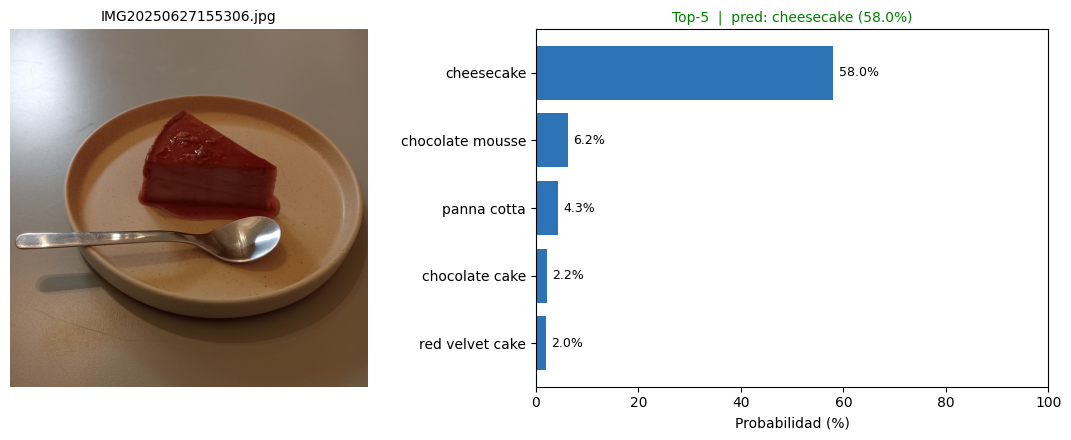

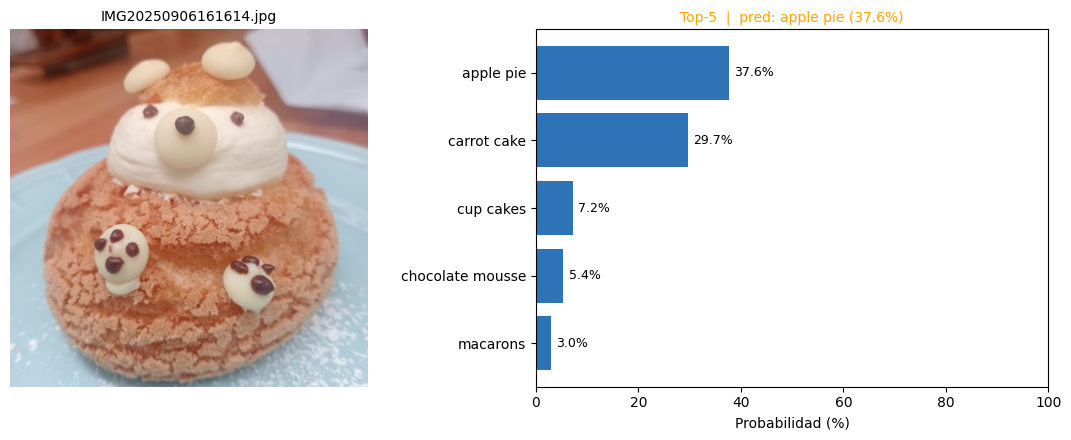

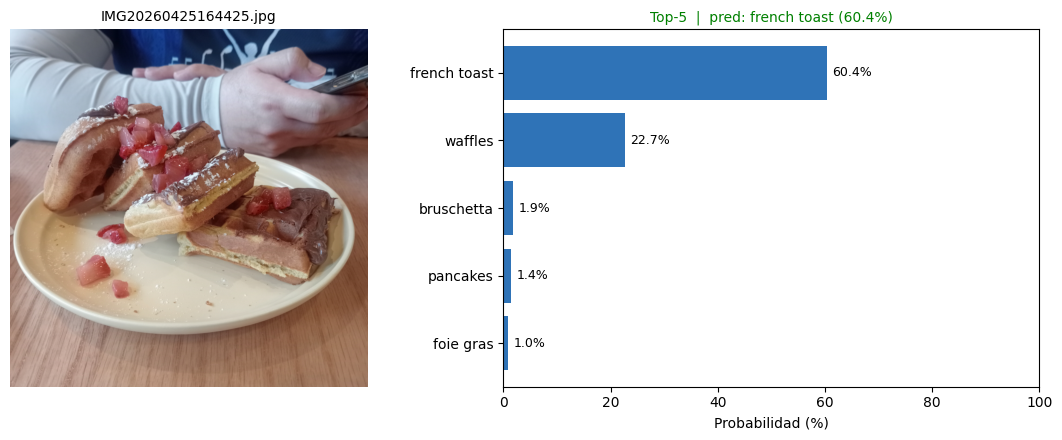

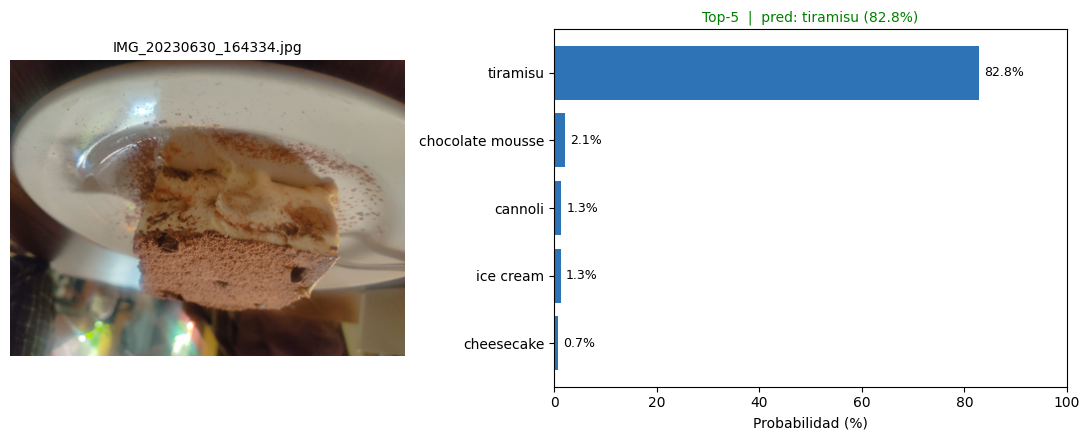

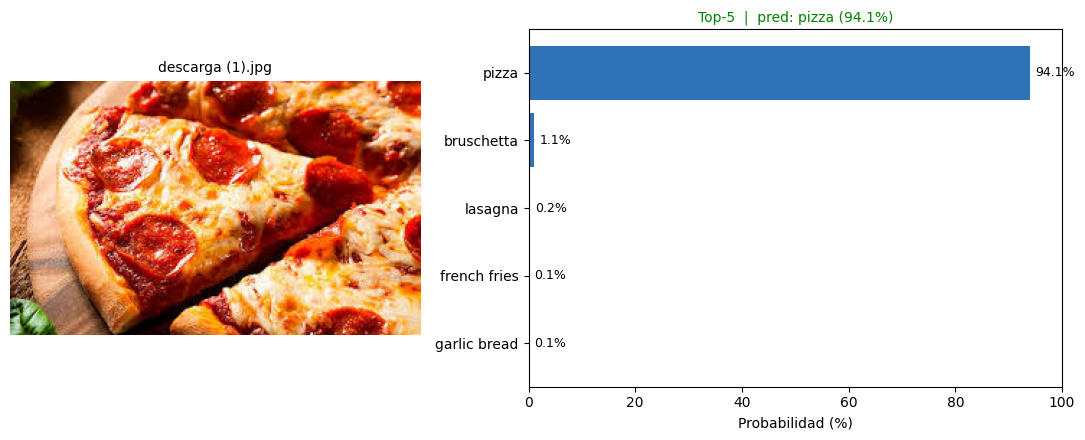

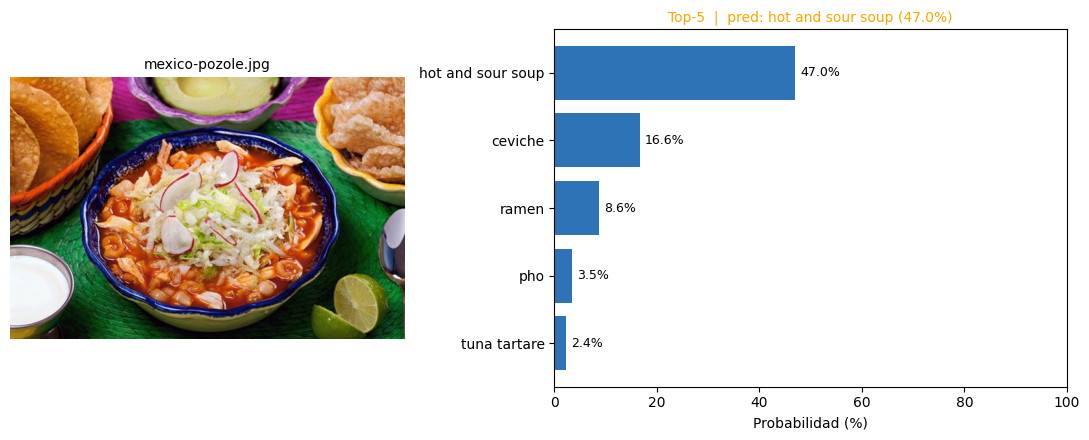

In [18]:
IMGS_DIR = 'data/prueba_food101'   # carpeta con .jpg/.png

if os.path.isdir(IMGS_DIR):
    paths = [os.path.join(IMGS_DIR, f) for f in sorted(os.listdir(IMGS_DIR))
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    n = len(paths)

    for p in paths:
        img, top5 = predecir(p, topk=5)
        names = [name for name, _ in top5][::-1]
        probs = [prob for _, prob in top5][::-1]

        fig, ax = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw={'width_ratios': [1, 1.3]})
        ax[0].imshow(img); ax[0].axis('off')
        ax[0].set_title(os.path.basename(p), fontsize=10)

        bars = ax[1].barh(names, [prob*100 for prob in probs], color='#2F73B7')
        ax[1].set_xlim(0, 100); ax[1].set_xlabel('Probabilidad (%)')
        ax[1].set_title(f'Top-5  |  pred: {top5[0][0]} ({top5[0][1]*100:.1f}%)',
                        fontsize=10, color='green' if top5[0][1] > 0.5 else 'orange')
        for bar, prob in zip(bars, probs):
            ax[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                       f'{prob*100:.1f}%', va='center', fontsize=9)
        plt.tight_layout(); plt.show()
else:
    print(f'No existe la carpeta {IMGS_DIR} (opcional).')
